### a) 
#### Implementar la función mascara_rayo(n, direccion, s), que devuelva una matriz Mr ∈ {0, 1} n×n con un 1 en los píxeles seleccionados por el rayo r y un 0 en los restantes.


In [2]:
def mascara_rayo(n, direccion, s):
    alpha, beta = direccion
    
    M = np.zeros((n, n), dtype=int) #crea una matriz llena de ceros.
    
    for i in range(n):
        for j in range(n): # recorre todos los píxeles.
            if alpha*i + beta*j == s:
                M[i, j] = 1 #marca con 1 los que cumplen la ecuación.
    
    return M

### b)
#### Visualizar las máscaras para las direcciones (1, 0), (0, 1), (1, 1), (1, −1) y (2, 1), utilizando respectivamente los desplazamientos s = 3, 5, 7, 0, 8.

In [3]:
direcciones = [(1,0), (0,1), (1,1), (1,-1), (2,1)]
desplazamientos = [3, 5, 7, 0, 8]


In [4]:
import numpy as np
mascaras = []

for direccion, s in zip(direcciones, desplazamientos): 
    M = mascara_rayo(8, direccion, s)
    mascaras.append(M)

zip(direcciones, desplazamientos): Une elemento con elemento.
es decir,
- (1,0)  -> 3
- (0,1)  -> 5
- (1,1)  -> 7
- (1,-1) -> 0
- (2,1)  -> 8

y para visualizarla:

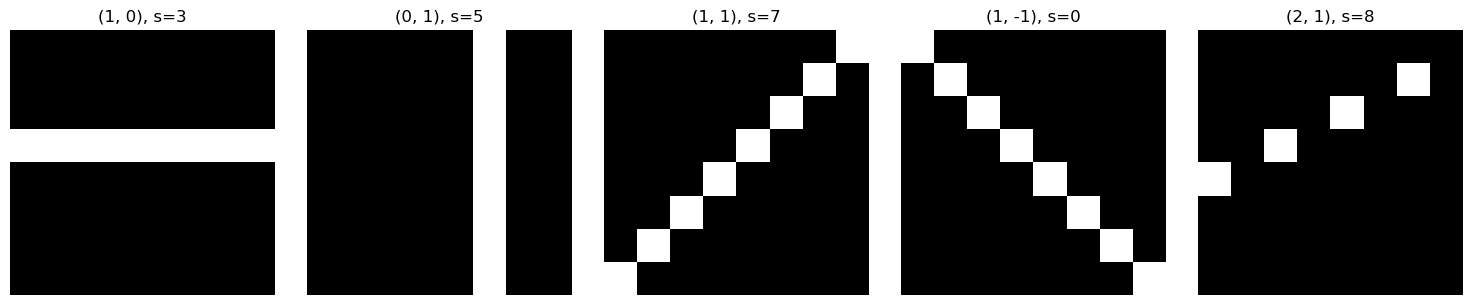

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,3))

for k, (direccion, s) in enumerate(zip(direcciones, desplazamientos)):
    
    M = mascara_rayo(8, direccion, s)
    
    plt.subplot(1, 5, k+1)
    plt.imshow(M, cmap="gray", vmin=0, vmax=1) #trata la máscara como una imagen 0 se ve oscuro, 1 se ve claro.
    plt.title(f"{direccion}, s={s}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### c)
#### Para cada máscara, calcular la medición br = i,j ∑(Mr)ij(Xfantoma) ij mediante un producto componente a componente entre la máscara y el fantoma.

La máscara solamente dice cuales son los píxeles que voy a mirar.

La medición aparece cuando usamos esa máscara sobre el fantoma.

La fórmula del enunciado es:

br = i,j ∑(Mr)ij(Xfantoma) ij

Osea hariamos por ejemplo:

Tomamos:

$$ M_r $$

y:

$$ X_{\text{fantoma}} $$

y los multiplicamos casillero por casillero.

Supongamos:

$$ M_r= \begin{pmatrix} 0&1\\ 1&0 \end{pmatrix} $$

y:
$$ X= \begin{pmatrix} 0.3&0.5\\ 0.8&0.3 \end{pmatrix} $$

Entonces:

$$ M_r * X= \begin{pmatrix} 0(0.3)&1(0.8)\\ 1(0.5)&0(0.3) \end{pmatrix} $$

queda:

$$ \begin{pmatrix} 0&0.8\\ 0.5&0 \end{pmatrix} $$

Y después sumamos:

$$ b_r=0.8+0.5=1.3 $$

Eso sería lo que mide el detector.
	​


In [8]:
import numpy as np
import matplotlib.pyplot as plt

X_fantoma = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
    [0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
    [0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
    [0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
    [0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
    [0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

In [9]:
M * X_fantoma

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.3, 0. , 0. , 0. ],
       [0. , 0. , 0.8, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]])

In [13]:
mediciones = []

for direccion, s in zip(direcciones, desplazamientos):
    
    M = mascara_rayo(8, direccion, s)
    
    b_r = np.sum(M * X_fantoma)
    
    mediciones.append(b_r)
    
    print(f"Dirección {direccion}, s={s}: b_r = {b_r}")

Dirección (1, 0), s=3: b_r = 2.3
Dirección (0, 1), s=5: b_r = 2.4
Dirección (1, 1), s=7: b_r = 1.2
Dirección (1, -1), s=0: b_r = 1.9000000000000001
Dirección (2, 1), s=8: b_r = 1.1


Hacemos manualmente el primero

Tenemos:

$$ (1,0),\quad s=3 $$

Como vimos:

$$ i=3 $$

Así que toma la fila 3 del fantoma:

$$ [0,\ 0.3,\ 0.8,\ 0.3,\ 0.3,\ 0.3,\ 0.3,\ 0] $$

La medición es:

$$ b_r= 0+0.3+0.8+0.3+0.3+0.3+0.3+0 $$

Entonces: br =2.3
	​


### d)
#### Explicar por qué dos rayos con orientaciones diferentes pueden producir el mismo valor de medición aunque seleccionen distintos píxeles.


Dos rayos con orientaciones diferentes pueden producir la misma medición aunque seleccionen píxeles distintos porque la medición br depende únicamente de la suma de los valores de atenuación de los píxeles seleccionados. Por lo tanto, diferentes conjuntos de píxeles pueden tener la misma suma total. El valor de la medición no permite identificar individualmente qué píxeles contribuyeron a ella.